# 05: Visualization

**Goal**: Create all final figures.

This notebook generates:
1. **Main results heatmap** (F1 scores: models × relation types)
2. **Relation type clustering** (dendrogram showing relation similarity)
3. **Model comparison** (violin plot — F1 distribution across relations)
4. **CLIP vs SBERT scatter** (per-relation comparison)

All figures saved as both .pdf and .png at 300dpi.

## 1. Setup and Load Results

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from dotenv import load_dotenv
import os

PROJECT_ROOT = (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()).resolve()
sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / ".env")

CACHE_DIR = Path(os.getenv("CACHE_DIR", "results/embeddings"))
if not CACHE_DIR.is_absolute():
    CACHE_DIR = PROJECT_ROOT / CACHE_DIR
RESULTS_DIR = PROJECT_ROOT / "results"

np.random.seed(42)
sns.set_style("whitegrid")
sns.set_palette("Set2")

plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.figsize"] = (12, 8)

print(f"Project root: {PROJECT_ROOT}")
print(f"Cache directory: {CACHE_DIR}")
print(f"Figures will be saved to: {RESULTS_DIR / 'figures'}")

Project root: /Users/norair/Documents/Code/Projects/spatial_probing
Cache directory: /Users/norair/Documents/Code/Projects/spatial_probing/results/embeddings
Figures will be saved to: /Users/norair/Documents/Code/Projects/spatial_probing/results/figures


## 2. Load All Results Data

In [2]:
from datasets import load_dataset

results_main = pd.read_csv(RESULTS_DIR / "probing_results.csv")
gains_df = pd.read_csv(RESULTS_DIR / "probing_results_with_gains.csv")

print(f"Loaded probing results: {len(results_main)} relations")
print(f"Columns: {list(results_main.columns)}")

print(f"\nLoading embeddings and dataset...")
embeddings_dict = {
    "SBERT": np.load(CACHE_DIR / "sbert_vsr_train.npy"),
    "CLIP Text": np.load(CACHE_DIR / "clip_text_vsr_train.npy"),
    "CLIP Image": np.load(CACHE_DIR / "clip_image_vsr_train.npy"),
}

vsr = load_dataset("cambridgeltl/vsr_random")
train_data = vsr["train"]
relation_labels = np.array([ex["relation"] for ex in train_data])

print(f"Dataset: {len(train_data)} examples")

/Users/norair/Documents/Code/Projects/spatial_probing/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded probing results: 36 relations
Columns: ['relation', 'sbert_f1', 'clip_text_f1', 'clip_image_f1', 'clip_concat_f1']

Loading embeddings and dataset...
Dataset: 7680 examples


## 3. Main Results Heatmap (Models × Relations)

In [ ]:
model_columns = ["sbert_f1", "clip_text_f1", "clip_image_f1"]
model_labels = ["SBERT", "CLIP Text", "CLIP Image"]

top_n = 25
top_relations = results_main.nlargest(top_n, "sbert_f1")["relation"].values
heatmap_subset = results_main[results_main["relation"].isin(top_relations)].set_index("relation")
heatmap_subset = heatmap_subset[model_columns].copy()
heatmap_subset.columns = model_labels

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(
    heatmap_subset,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "F1 Score"},
    ax=ax,
    linewidths=0.5,
    linecolor="gray",
    annot_kws={"fontsize": 9, "fontweight": "bold"},
)
ax.set_title(f"Probing Results: Spatial Relation Decodability\nTop {top_n} relations by SBERT F1",
            fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Model", fontsize=12, fontweight="bold")
ax.set_ylabel("Spatial Relation Type", fontsize=12, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), fontweight="bold")
plt.tight_layout()

plt.savefig(RESULTS_DIR / "figures" / "05_main_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 05_main_heatmap.png")

## 4. Relation Type Clustering (Dendrogram by CLIP Similarity)

In [ ]:
RELATION_CATEGORY = {
    # Projective — directional, frame-of-reference position (Levinson, 2003)
    "above": "projective", "below": "projective", "under": "projective",
    "beneath": "projective", "over": "projective", "on top of": "projective",
    "left of": "projective", "right of": "projective",
    "in front of": "projective", "behind": "projective",
    "at the left side of": "projective", "at the right side of": "projective",
    "at the back of": "projective", "facing": "projective",
    "facing away from": "projective",
    # Topological — contact, containment, proximity (Levinson, 2003)
    "inside": "topological", "on": "topological", "touching": "topological",
    "contains": "topological", "in": "topological", "part of": "topological",
    "surrounding": "topological", "in the middle of": "topological",
    "at the edge of": "topological", "off": "topological",
    "near": "topological", "close to": "topological", "far from": "topological",
    "far away from": "topological", "away from": "topological",
    "next to": "topological", "beside": "topological", "adjacent to": "topological",
    "across from": "topological", "parallel to": "topological",
    "perpendicular to": "topological",
}

CATEGORY_COLORS = {
    "projective": "steelblue",
    "topological": "forestgreen",
}

# Filter to the 36 probed relations only
probed_relations = set(results_main["relation"].tolist())
clip_text_emb = embeddings_dict["CLIP Text"]

relation_embeddings = {}
for relation in np.unique(relation_labels):
    if relation not in probed_relations:
        continue
    indices = np.where(relation_labels == relation)[0]
    relation_embeddings[relation] = clip_text_emb[indices].mean(axis=0)

relation_names = sorted(list(relation_embeddings.keys()))
relation_embs = np.array([relation_embeddings[r] for r in relation_names])

pdist_vals = pdist(relation_embs, metric="cosine")
linkage_matrix = linkage(pdist_vals, method="average")

# Build link_color_func: color a branch by category if all its leaves share one,
# otherwise gray. link_color_func receives the internal node id (n_leaves + row_idx).
n_leaves = len(relation_names)
leaf_cats = [RELATION_CATEGORY.get(name, "unknown") for name in relation_names]

_node_cat_cache = {}
def _get_node_cats(node_id):
    if node_id in _node_cat_cache:
        return _node_cat_cache[node_id]
    if node_id < n_leaves:
        result = frozenset([leaf_cats[node_id]])
    else:
        row = linkage_matrix[node_id - n_leaves]
        result = _get_node_cats(int(row[0])) | _get_node_cats(int(row[1]))
    _node_cat_cache[node_id] = result
    return result

def link_color_func(node_id):
    cats = _get_node_cats(node_id)
    if len(cats) == 1:
        return CATEGORY_COLORS.get(next(iter(cats)), "#aaaaaa")
    return "#aaaaaa"

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(
    linkage_matrix, labels=relation_names, ax=ax,
    leaf_font_size=9, link_color_func=link_color_func,
)
for coll in ax.collections:
    coll.set_linewidth(3.5)
ax.set_title("Relation Type Clustering by CLIP Text Embedding Similarity",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Spatial Relation Type", fontsize=12)
ax.set_ylabel("Distance (cosine dissimilarity)", fontsize=12)
plt.xticks(rotation=90)

for label in ax.get_xticklabels():
    cat = RELATION_CATEGORY.get(label.get_text(), "unknown")
    label.set_color(CATEGORY_COLORS.get(cat, "black"))

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=CATEGORY_COLORS["projective"], lw=3, label="Projective"),
    Line2D([0], [0], color=CATEGORY_COLORS["topological"], lw=3, label="Topological"),
    Line2D([0], [0], color=CATEGORY_COLORS["proximal"], lw=3, label="Proximal"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=11)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "05_relation_dendrogram.pdf", dpi=300, bbox_inches="tight")
plt.savefig(RESULTS_DIR / "figures" / "05_relation_dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 05_relation_dendrogram.pdf/png")

## 5. Model Comparison — Performance Distribution

In [ ]:
data_for_plot = []
for col, model in [("sbert_f1", "SBERT"), ("clip_text_f1", "CLIP Text"), ("clip_image_f1", "CLIP Image"), ("clip_concat_f1", "CLIP Concat")]:
    for f1 in results_main[col]:
        data_for_plot.append({"Model": model, "F1 Score": f1})

df_plot = pd.DataFrame(data_for_plot)

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=df_plot, x="Model", y="F1 Score", hue="Model", legend=False, ax=ax, palette="Set2")
ax.set_title("F1 Score Distribution across Relations", fontsize=13, fontweight="bold")
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_ylim([0, 1])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "05_model_comparison.pdf", dpi=300, bbox_inches="tight")
plt.savefig(RESULTS_DIR / "figures" / "05_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 05_model_comparison.pdf/png")

## 6. CLIP Gains over SBERT

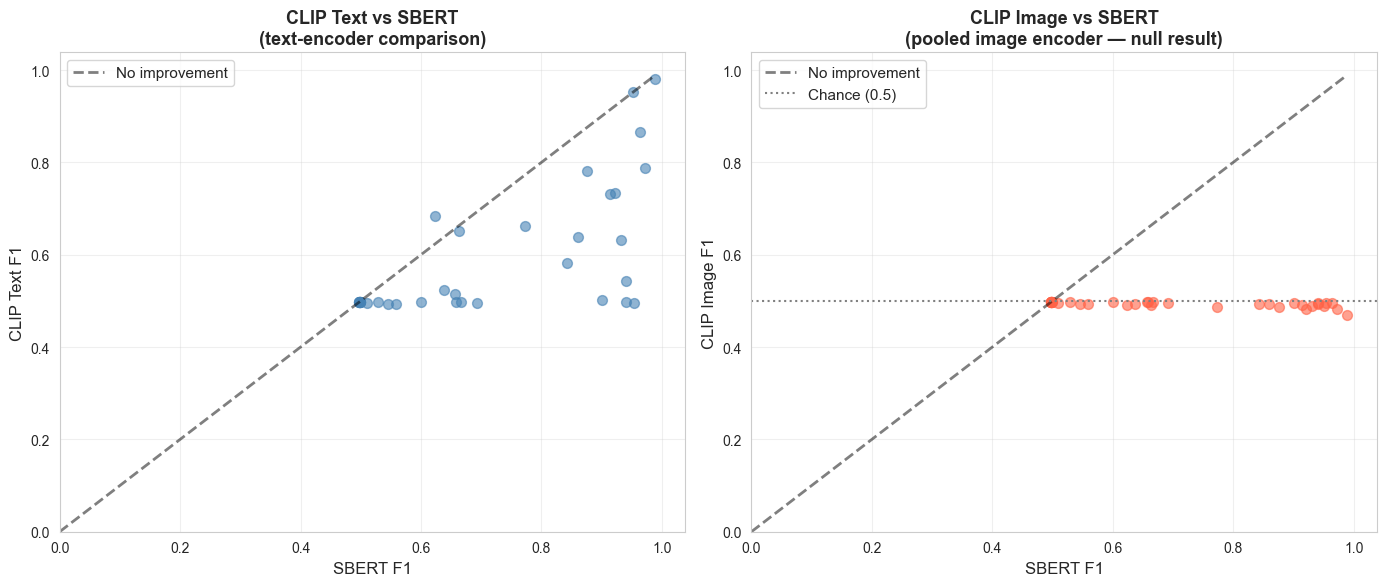

Saved: 05_clip_gains.pdf/png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
max_val = max(results_main["sbert_f1"].max(), results_main["clip_text_f1"].max())

# CLIP text vs SBERT — the main text-encoder comparison
ax1.scatter(results_main["sbert_f1"], results_main["clip_text_f1"], alpha=0.6, s=50, color="steelblue")
ax1.plot([0, max_val], [0, max_val], "k--", lw=2, alpha=0.5, label="No improvement")
ax1.set_xlim([0, max_val * 1.05])
ax1.set_ylim([0, max_val * 1.05])
ax1.set_xlabel("SBERT F1", fontsize=12)
ax1.set_ylabel("CLIP Text F1", fontsize=12)
ax1.set_title("CLIP Text vs SBERT\n(text-encoder comparison)", fontsize=13, fontweight="bold")
ax1.legend()
ax1.grid(alpha=0.3)

# CLIP image vs SBERT — shows null result for image encoder
ax2.scatter(results_main["sbert_f1"], results_main["clip_image_f1"], alpha=0.6, s=50, color="tomato")
ax2.plot([0, max_val], [0, max_val], "k--", lw=2, alpha=0.5, label="No improvement")
ax2.axhline(0.5, color="gray", linestyle=":", lw=1.5, label="Chance (0.5)")
ax2.set_xlim([0, max_val * 1.05])
ax2.set_ylim([0, max_val * 1.05])
ax2.set_xlabel("SBERT F1", fontsize=12)
ax2.set_ylabel("CLIP Image F1", fontsize=12)
ax2.set_title("CLIP Image vs SBERT\n(pooled image encoder — null result)", fontsize=13, fontweight="bold")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "05_clip_gains.pdf", dpi=300, bbox_inches="tight")
plt.savefig(RESULTS_DIR / "figures" / "05_clip_gains.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 05_clip_gains.pdf/png")

## 8. Summary Table

In [8]:
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

summary_stats = []
for model, col in [("SBERT", "sbert_f1"), ("CLIP Text", "clip_text_f1"), ("CLIP Image", "clip_image_f1"), ("CLIP Concat", "clip_concat_f1")]:
    f1_scores = results_main[col]
    summary_stats.append({
        "Model": model,
        "Mean F1": f1_scores.mean(),
        "Std F1": f1_scores.std(),
        "Median F1": f1_scores.median(),
        "Min F1": f1_scores.min(),
        "Max F1": f1_scores.max(),
        "N Relations": len(f1_scores),
    })

summary_df = pd.DataFrame(summary_stats)
print(summary_df.round(3).to_string(index=False))

summary_df.to_csv(RESULTS_DIR / "summary_statistics.csv", index=False)
print(f"\nSaved: summary_statistics.csv")

print("\n" + "="*80)
print("VISUALIZATIONS COMPLETE")
print("="*80)
print(f"\nAll figures saved to: {RESULTS_DIR / 'figures'}")
for fig_file in sorted((RESULTS_DIR / "figures").glob("05_*.png")):
    print(f"  ✓ {fig_file.name}")


FINAL RESULTS SUMMARY
      Model  Mean F1  Std F1  Median F1  Min F1  Max F1  N Relations
      SBERT    0.710   0.188      0.661   0.497   0.989           36
  CLIP Text    0.589   0.139      0.498   0.493   0.981           36
 CLIP Image    0.493   0.006      0.495   0.469   0.498           36
CLIP Concat    0.514   0.077      0.496   0.484   0.902           36

Saved: summary_statistics.csv

VISUALIZATIONS COMPLETE

All figures saved to: /Users/norair/Documents/Code/Projects/spatial_probing/results/figures
  ✓ 05_clip_gains.png
  ✓ 05_main_heatmap.png
  ✓ 05_model_comparison.png
  ✓ 05_relation_dendrogram.png
